<a href="https://colab.research.google.com/github/gladysHinestroza/gladysHinestroza/blob/main/Water_Quality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water Quality Analysis

---
## Introduction
 Monotoring the water quality in various sampling stations is necessary for identifying spatial variation in environmental conditions and detecting potential areas of concern. Differences in measurements such as turbidity may indicate localized pollution sources, sediment disturbances, or infrastructure issues that affect water clarity and ecosystem health.

 The question guiding the analysis is: Are there significant differences in water quality at different sampling stations? To investigate, water measurements (Top_Turbidity_NTU) were compared across sampling locations using statistical modeling techniques.

 The dataset used for the analysis, H2OQuality, contains water quality observations collected from a number of sampling stations. Key variables include Sampling Location, a categorical variable which identifies monotoring sites, and Top_Turbidity_NTU, a qualitative measure of water clarity expressed in Nephelometric Turbidity Units (NTU). These measures allow for evaluation of whether turbidity levels vary significantly between locations, which may suggest differences in environmental conditions across stations.



---






---

## Analysis

To determine whether water quality differs across sampling stations, exploratory data analysis (EDA) and an inferential statistical model were performed using turbidity measurements (Top_Turbidity_NTU) as the response variable and Sampling Location as the categorical predictor.

The dataset H2OQualityNew.csv was first imported and inspected using .info() to verify variable structure and data types. Because column names contained spaces and long descriptive labels, variables were renamed to improve usability during modeling. Specifically:

"Top Turbidity(Nephelometric Turbidity Units)" was renamed to Top_Turbidity_NTU
"Sampling Location" was retained as the categorical grouping variable

Rows containing missing values in the selected variables were removed using .dropna() to ensure valid model estimation. After cleaning, the dataset contained 7,923 observations.

The sampling location variable was treated as a categorical factor using: C(Q('Sampling Location')) so that turbidity levels could be compared across monitoring stations.

Exploratory analysis confirmed that:

*  Sampling locations contained multiple monitoring stations
*  Turbidity values varied substantially across locations
*  No missing values remained in the selected modeling variables
*  The dataset size remained sufficiently large for reliable inference

Because sampling location is categorical and turbidity is continuous, a one-way ANOVA via OLS regression was selected as the appropriate modeling approach.
A linear regression model equivalent to a one-way ANOVA was fit:

Top_Turbidity_NTU∼Sampling Location

This model evaluates whether mean turbidity differs significantly across stations.

The regression output showed:

F-statistic = 19.65

p-value < 0.001

R² = 0.226

##### The statistically significant F-test indicates that at least one sampling station has a mean turbidity level different from the others.
<br>

Statistic | Value | Interpretation
--- | --- | ---
Observations | 7,923 | Large sample size supports reliable inference
R² | 0.226 | Sampling location explains 22.6% of turbidity variation
F-statistic | 19.65 | Indicates overall model significance
p-value | <0.001 | Strong evidence of differents among stations

<br>

The statistically significant F-test indicates that at least one sampling station has a mean turbidity level different from the others.
The regression coefficients associated with individual sampling stations represent deviations from the reference location’s turbidity level. Many sampling stations had statistically significant negative coefficients, indicating lower turbidity relative to the baseline station. This suggests measurable spatial variation in water clarity across monitoring sites.

##### Overall, the inferential results provide strong statistical evidence that water turbidity differs significantly among sampling locations, supporting the hypothesis that sampling station location influences measured water quality.
---






---

## Results
To determine whether water quality differed across sampling stations, a one-way ANOVA implemented through an ordinary least squares (OLS) regression model was fit with Top_Turbidity_NTU as the response variable and Sampling Location as the categorical predictor.

The overall regression model was statistically significant:


*  F(116, 7806) = 19.65
*  p < 0.001
*  R² = 0.226

These results indicate that mean turbidity levels vary significantly across sampling locations. Approximately 22.6% of the variability in turbidity measurements is explained by differences among stations, suggesting that sampling location is an important factor influencing water clarity.

The intercept represents the estimated mean turbidity at the reference sampling station, which was approximately 44.12 NTU. Many sampling locations showed statistically significant negative coefficients relative to this baseline location, indicating lower turbidity levels at those stations.

These statistically significant differences demonstrate substantial variation in turbidity across monitoring sites.

Overall, the inferential analysis provides strong evidence that water quality, as measured by turbidity, differs across sampling stations, supporting the conclusion that location plays a meaningful role in explaining variation in turbidity levels.



---






---

## Discussion
The statistical analysis shows that water quality is not the same across all sampling stations. In particular, turbidity levels which measure how clear or cloudy the water is vary significantly depending on where the sample was collected.

Some stations consistently showed much lower turbidity than the reference location, meaning the water at those sites was clearer. Because these differences were large and consistent across many locations, they are unlikely to be due to random variation. Instead, they suggest that conditions affecting water clarity differ from place to place.

Although sampling location explains a meaningful portion of the variation in turbidity (about 23%), other factors not included in this analysis such as rainfall, nearby land use, sediment runoff, or seasonal effects may also influence water quality.

Overall, the results support the conclusion that sampling location plays an important role in determining water quality, and that turbidity levels differ significantly between monitoring stations. This suggests that some areas may require closer monitoring or further investigation to better understand the causes of reduced water clarity.



---






---

## Code



---




In [ ]:
from google.colab import drive
drive.mount('/gdrive')
# Mounting google drive

Mounted at /gdrive


In [ ]:
import statsmodels as sms
import statsmodels.formula.api as smf
import statsmodels.api as smapi
import statsmodels.stats as smstats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as bc
# Importing necessary packages for the assignment

In [ ]:
file_path = '/gdrive/MyDrive/H2OQualityNew.csv'
H2OQualityNew = pd.read_csv(file_path, low_memory=False)
H2OQualityNew.info()
# Importing dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83437 entries, 0 to 83436
Data columns (total 13 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            83437 non-null  int64  
 1   Sampling Location                                     83437 non-null  object 
 2   Duplicate Sample                                      404 non-null    object 
 3   Sample Date                                           83437 non-null  object 
 4   Top Sample Temperature (ºC)                           66354 non-null  float64
 5   Bottom Sample Temperature (ºC)                        65409 non-null  float64
 6   Top Turbidity( Nephelometric Turbidity Units)         7944 non-null   float64
 7   Bottom Turbidity YSI (Nephelometric Turbidity Units)  2528 non-null   float64
 8   Oakwood BOD Top Sample (mg/L)                         15

In [ ]:
H2OQualityNew = H2OQualityNew.rename(columns={'Top Turbidity( Nephelometric Turbidity Units)': 'Top_Turbidity_NTU'})
# Renaming Turbidity
H2OQualityNew = H2OQualityNew[['Sampling Location', 'Top_Turbidity_NTU']].dropna()
# Dropping missing values

In [ ]:
df = H2OQualityNew[['Sampling Location', 'Top_Turbidity_NTU']].dropna().copy()
df = df[df['Top_Turbidity_NTU'] > 0]
# Dropping missing values

In [ ]:
df['Turbidity_BC'], lambda_bc = bc.boxcox(df['Top_Turbidity_NTU'])
print(lambda_bc)
# box cox transformatrion

-0.006802668991547509


<Axes: >

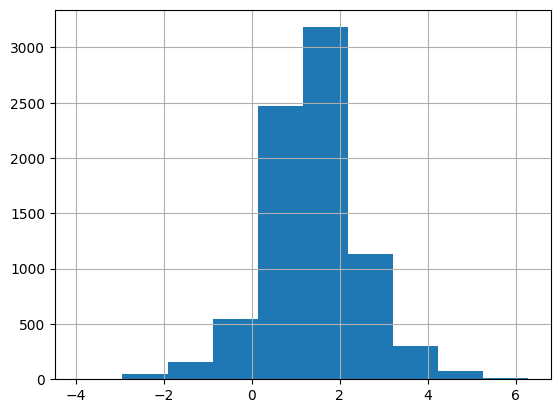

In [ ]:
df['Turbidity_BC'].hist()
# histogram of Turbidity after box cox transformation to check normality

In [ ]:
model_bc = smf.ols("Turbidity_BC ~ C(Q('Sampling Location'))", data = df).fit()
# Defining and fitting the model after box cox transformation
model_bc.summary()
# Model summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Turbidity_BC   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     33.81
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        21:17:37   Log-Likelihood:                -10235.
No. Observations:                7923   AIC:                         2.070e+04
Df Residuals:                    7806   BIC:                         2.152e+04
Df Model:                         116                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             3.1652      0.049     64.418      0.000       3.069       3.262
C(Q('Sampling Location'))[T.AC2]     -0.5104      0.085     -5.998      0.000      -0.677      -0.344
C(Q('Sampling Location'))[T.BB2]     -2.2267      0.515     -4.327      0.000      -3.235      -1.218
C(Q('Sampling Location'))[T.BB4]     -2.7849      0.188    -14.842      0.000      -3.153      -2.417
C(Q('Sampling Location'))[T.BR1]     -2.5177      0.074    -34.021      0.000      -2.663      -2.373
C(Q('Sampling Location'))[T.BR3]     -1.3227      0.074    -17.854      0.000      -1.468      -1.177
C(Q('Sampling Location'))[T.BR5]     -1.2291      0.515     -2.389      0.017      -2.238      -0.220
C(Q('Sampling Location'))[T.CIC2]    -2.2989      0.072    -31.983      0.000      -2.440      -2.158
C(Q('Sampling Location'))[T.CIC3]    -2.6613      0.339     -7.853      0.000      -3.326      -1.997
C(Q('Sampling Location'))[T.E1]      -1.4893      0.251     -5.936      0.000      -1.981      -0.997
C(Q('Sampling Location'))[T.E10]     -2.2562      0.204    -11.040      0.000      -2.657      -1.856
C(Q('Sampling Location'))[T.E11]     -1.8642      0.181    -10.311      0.000      -2.219      -1.510
C(Q('Sampling Location'))[T.E12]     -2.1893      0.089    -24.662      0.000      -2.363      -2.015
C(Q('Sampling Location'))[T.E13]     -2.1099      0.085    -24.792      0.000      -2.277      -1.943
C(Q('Sampling Location'))[T.E14]     -1.5833      0.227     -6.970      0.000      -2.029      -1.138
C(Q('Sampling Location'))[T.E15]     -1.4803      0.234     -6.318      0.000      -1.940      -1.021
C(Q('Sampling Location'))[T.E2]      -1.4184      0.162     -8.752      0.000      -1.736      -1.101
C(Q('Sampling Location'))[T.E2A]     -1.5085      0.285     -5.296      0.000      -2.067      -0.950
C(Q('Sampling Location'))[T.E3]      -1.4603      0.272     -5.369      0.000      -1.993      -0.927
C(Q('Sampling Location'))[T.E4]      -1.4787      0.156     -9.490      0.000      -1.784      -1.173
C(Q('Sampling Location'))[T.E5]      -1.5073      0.285     -5.292      0.000      -2.066      -0.949
C(Q('Sampling Location'))[T.E6]      -1.7899      0.164    -10.891      0.000      -2.112      -1.468
C(Q('Sampling Location'))[T.E7]      -2.1074      0.160    -13.181      0.000      -2.421      -1.794
C(Q('Sampling Location'))[T.E8]      -2.2331      0.156    -14.332      0.000      -2.539      -1.928
C(Q('Sampling Location'))[T.E9]      -2.0294      0.285     -7.125      0.000      -2.588      -1.471
C(Q('Sampling Location'))[T.EJ1]     -1.3948      0.234     -5.954      0.000      -1.854      -0.936
C(Q('Sampling Location'))[T.EJ7]     -2.0359      0.234     -8.690      0.000      -2.495      -1.577
C(Q('Sampling Location'

In [ ]:
smstats.diagnostic.normal_ad(model_bc.resid)
# Testing for normality

(np.float64(49.9406170230759), 0.0)

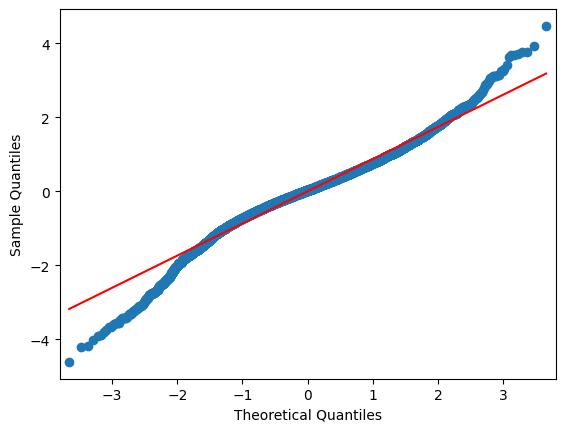

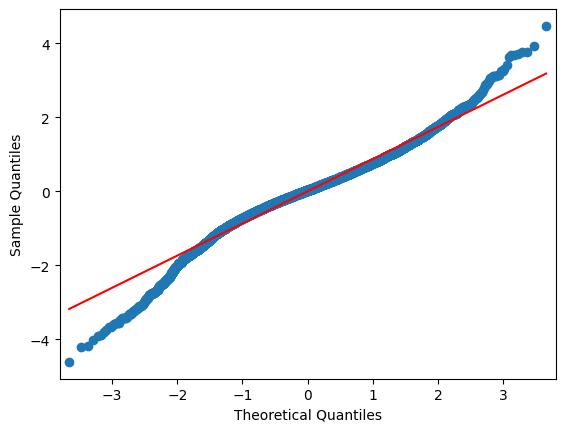

In [ ]:
smapi.qqplot(model_bc.resid, line = 'r')
# Created a qq plot of the residuals

In [ ]:
smstats.diagnostic.het_breuschpagan(model_bc.resid, model_bc.model.exog)
# Testing for equal variance (returns 4 arguments; 'the Lagrange multiplier statistic', 'p-value','f-value', 'f p-value')

(np.float64(367.9721749113088),
 np.float64(5.500319621369783e-28),
 np.float64(3.277551083288444),
 np.float64(6.953034869882801e-29))

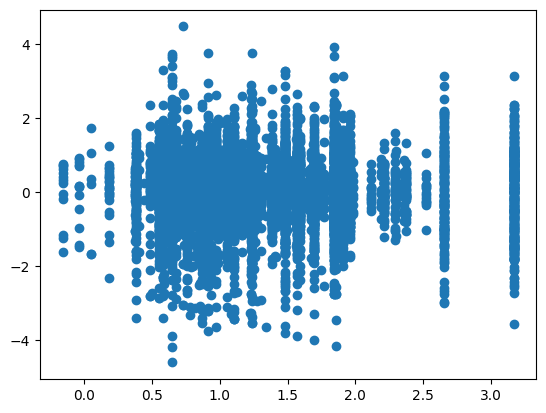

In [ ]:
plt.scatter(model_bc.fittedvalues, model_bc.resid)
# Scatter plot of residuals vs fit